#Homework1:

## Partial Dependence Plot (PDP)

Calculate PDP values for the feature CoapplicantIncome, and see if you can make the curve change trend
just by changing the included range.
What does this tell us? What do you know about outliers in machine learning?

### Read and process data

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

from itertools import chain, combinations, product
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"

seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
!git clone https://github.com/strumke/AIMS_XAI_Inga.git


Cloning into 'AIMS_XAI_Inga'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 122 (delta 18), reused 13 (delta 13), pack-reused 103 (from 1)
Receiving objects: 100% (122/122), 34.31 MiB | 17.34 MiB/s, done.
Resolving deltas: 100% (40/40), done.


In [ ]:
filepath="AIMS_XAI_Inga/data/LoanApprovalPrediction.csv"
with open(filepath, "r") as file:
    data_frame = pd.read_csv(file)
# Remove all rows with nan values
data_frame = data_frame.dropna()

In [ ]:
print(len(data_frame.columns))

13


In [ ]:
categorical_feature_names= ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Credit_History", "Dependents"]
continuous_feature_names= ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
drop_column = "Loan_ID" # Not included as the value is unique for each row
label_column = "Loan_Status"

In [ ]:
def get_preprocessors(data_frame:pd.DataFrame, categorical_feature_names:list, continuous_feature_names:list):
  categories_per_feature = [
    sorted(data_frame[col].unique().tolist()) for col in categorical_feature_names]
  ohencoder = OneHotEncoder(categories=categories_per_feature)
  scaler = StandardScaler()
  labelencoder = LabelEncoder()
  return ohencoder, scaler, labelencoder

In [ ]:
ohencoder, scaler, labelencoder = get_preprocessors(data_frame, categorical_feature_names, continuous_feature_names)

In [ ]:
def preprocess_data(df: pd.DataFrame, continuous_feature_names: list[str], categorical_feature_names: list[str], label_column=str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parameters:
        df (pd.DataFrame): the data in pandas dataframe format
        continuous_feature_names (list[str]): list of the feature names where the feature is continuous
        categorical_feature_names (list[str]): list of the feature names where the feature is categorical
        label_column (str): name of the label
    Returns:
        tuple[pd.DataFrame, pd.Dataframe]: preprocessed feature values and preprocessed labels
    """
    # Fit data, using a scaler for continuous data, oheencoder for categorical data and a labelencoder for the target values (label)
    continuous_features = scaler.transform(df[continuous_feature_names])
    categorical_features = ohencoder.transform(df[categorical_feature_names]).toarray()
    labels = labelencoder.transform(df[label_column])

    # Convert to tensors and using the available device
    continuous_features = torch.tensor(continuous_features, dtype=torch.float32, device=device)
    categorical_features = torch.tensor(categorical_features, dtype=torch.float32, device=device)
    labels = torch.tensor(labels, dtype=torch.float32, device=device)
    preprocessed_features = torch.hstack((continuous_features, categorical_features))

    return preprocessed_features, labels

In [ ]:
df = data_frame.copy(deep=True) # we will use the raw data later and do not want to modify in place
scaler.fit(df[continuous_feature_names])
ohencoder.fit(df[categorical_feature_names])
labelencoder.fit(df[label_column])
preprocessed_data, labels = preprocess_data(df, continuous_feature_names, categorical_feature_names, label_column)

X_train, X_test, y_train, y_test = train_test_split(preprocessed_data, labels, random_state=42, test_size=0.2)
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32)

### Create and train model

In [ ]:
class Network(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.f1 = nn.Linear(input_dim, 64)
        self.f2 = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor):
        x = F.relu(self.f1(x))
        x = self.f2(x)
        return x

In [ ]:
def train_one_epoch(train_loader, model):
    model.train()
    for X, y in train_loader:
        optimizer.zero_grad()
        outputs = model(X).squeeze(-1)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test).squeeze(-1)
        loss = loss_fn(outputs, y_test)
        preds = torch.sigmoid(outputs)
        accuracy = sum((preds > 0.5) == y_test)/len(y_test)
    return loss, accuracy

In [ ]:
input_dim = len(X_train[0])
model = Network(input_dim).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.03)

In [ ]:
for _ in range(100):
    loss, accuracy = train_one_epoch(train_loader, model)
print("Loss:", loss.item(), "\nAccuracy:", accuracy.item())

Loss: 0.37547656893730164 
Accuracy: 0.8613861203193665


### Partial dependence plots

We want to marginalize over all other features $\boldsymbol{x}_C$ so the function show the relationship between features (or feature) in set $S$:
$$
\hat{f}_S(\boldsymbol{x}_S) = \frac{1}{n}\sum^n_{i=1} \hat{f}(\boldsymbol{x}_S, \boldsymbol{x}_C^{(i)})
$$

First let us consider one categorical feature

In [ ]:
def create_modified_df(df: pd.DataFrame, feature: str, values: list) -> [dict[str, pd.DataFrame]]:
    """
    Parameters:
        df (pd.DataFrame): data
        feature (str): name of the feature that should be modified
        values (list): the possible values of the feature
    Returns:
        dict[str, pd.DataFrame]: set of dataframes where the the rows of the feature are set to the same value.
    """
    dfs = {}
    for value in values:
        df.loc[:, feature] = value
        dfs[value] = df.copy(deep=True)
    return dfs

In [ ]:
def get_marginalized_probability(df:pd.DataFrame, continuous_feature_names:list,
                                 categorical_feature_names:list, label_column:str)->float:
    """
    Parameters:
        df (pd.DataFrame): data
        continuous_feature_names (list): names of continuous feaures
        categorical_feature_names (list): names of categorical features
        label_column (str): header of the target column
    Returns:
        float: the mean sigmoid prediction for the dataframe.
    """
    preprocessed_data, labels = preprocess_data(df, continuous_feature_names, categorical_feature_names, label_column)

    outputs = model(preprocessed_data).squeeze(-1)
    preds = torch.sigmoid(outputs)
    return float(preds.mean().item())

### PDP for the feature `CoapplicantIncome`

In [ ]:
def get_pdp_function(dataframe, feature_name, continuous_feature_names, categorical_feature_names, values, label):
    #create the new datasets
    mod_dfs = create_modified_df(dataframe.copy(deep=True),feature_name, values)
    probabilities = {}
    for val in values:
        probabilities[val]= get_marginalized_probability(mod_dfs[val], continuous_feature_names, categorical_feature_names, label)
    return probabilities

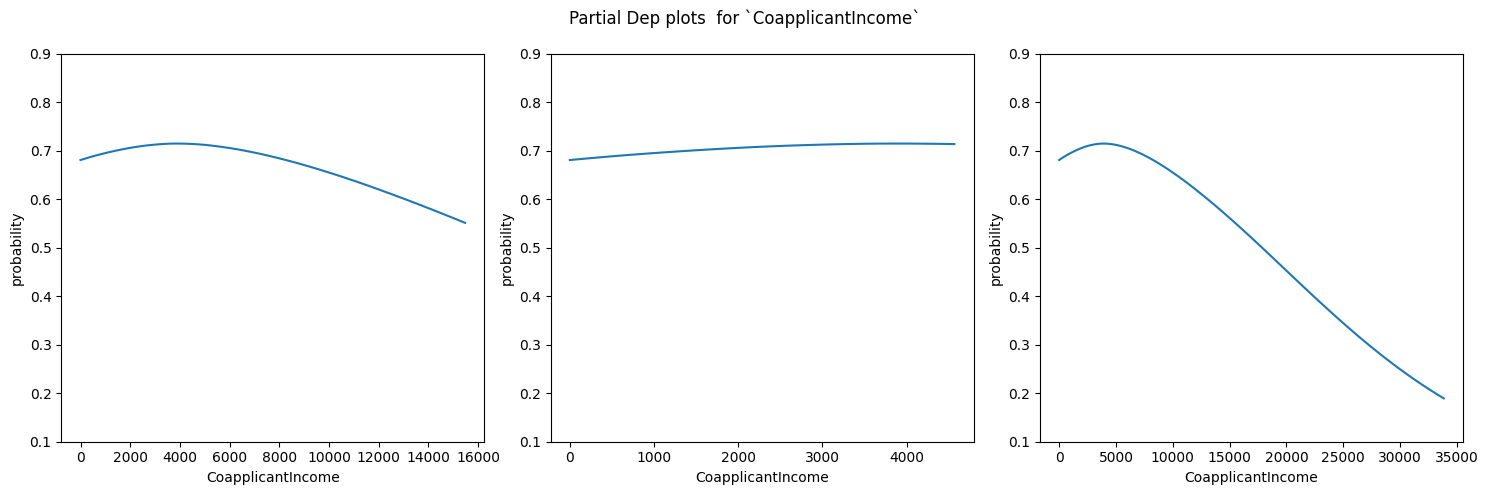

In [ ]:
n=100
feature_name = "CoapplicantIncome"
up =np.quantile(data_frame[feature_name].values, 0.995)
up_1=np.quantile(data_frame[feature_name].values, 0.94)
low = np.quantile(data_frame[feature_name].values, 0.005)
low_1=np.quantile(data_frame[feature_name].values, 0.05)

values = np.linspace(low, up, n)
v_1 = np.linspace(low_1, up_1, n)
v_2 = np.linspace(data_frame[feature_name].min(), data_frame[feature_name].max(), n)
#print("values", min(values), max(values))
pdp_1 = get_pdp_function(data_frame.copy(deep=True), feature_name, continuous_feature_names, categorical_feature_names, v_1, label_column)
pdp = get_pdp_function(data_frame.copy(deep=True), feature_name, continuous_feature_names, categorical_feature_names, values, label_column)
pdp_2 = get_pdp_function(data_frame.copy(deep=True), feature_name, continuous_feature_names, categorical_feature_names, v_2, label_column)
pdps = [pdp, pdp_1, pdp_2]

#print("probs",pdp)
fig, axes = plt.subplots(1,len(pdps), figsize=(15,5))

#print("probs", pdp_1)
for i, pdp in enumerate(pdps):
  ax = axes[i]
  ax.plot(pdp.keys(), pdp.values())
  ax.set_xlabel(feature_name)
  ax.set_ylabel("probability")
  ax.set_ylim(0.1, 0.9)
fig.suptitle("Partial Dep plots  for `CoapplicantIncome`")
fig.tight_layout()
plt.show()

We notice that with different interval ranges choosen, pdp curve has different trends. that means that, the outliers values in Coapplicantincome, gives extreme values for the average prediction marginalized over the other features.

We can say that Machine Learning Models are very sensitives to outliers values in their inputs.

## Accumulated Local Effects (ALE)

## part2: Write the ALE function

In [ ]:
import math
from typing import Callable, Literal

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor

import torch
from torch.utils.data import DataLoader, TensorDataset

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
X, y = fetch_california_housing(as_frame=True, return_X_y=True)
train_df = pd.concat([X, y], axis=1).dropna() # Remove all rows with NaN values
X = train_df[X.columns]
y = train_df[y.name]
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
df = X.assign(MedHouseVal=y)
feature_names = X_train.columns.tolist()

In [ ]:
numerical_transformer = Pipeline([
])
preprocessor = ColumnTransformer(
    transformers = [
        ('scaler', StandardScaler(), feature_names)
    ],
    remainder = "drop"
)


pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor()),
])

In [ ]:
pipe.fit(X_train, y_train)
print("Accuracy:", pipe.score(X_test, y_test))

Accuracy: 0.7817180345916585


### ALE estimation for a single feature
The explanations for the equations can be found in the [interpretable ml book](https://christophm.github.io/interpretable-ml-book/ale.html).

(1) First we estimate the uncentered effect:
$$
\hat{\tilde{f}}_{j,ALE}(\mathbf{x}) = \sum_{k=1}^{k_j(\mathbf{x})} \frac{1}{n_j(k)} \sum_{i: x_j^{(i)} \in N_j(k)} \left[\hat{f}(z_{k,j}, \mathbf{x}^{(i)}_{-j}) - \hat{f}(z_{k-1,j}, \mathbf{x}^{(i)}_{-j})\right]
$$
(2) Then we center the effect so that the mean effect is zero:
$$
\hat f_{j,\text{ALE}}(\mathbf{x}) = \hat{\tilde f}_{j,\text{ALE}}(\mathbf{x}) \;-\; \frac1n \sum_{i=1}^n \hat{\tilde f}_{j,\text{ALE}}\!\big(\mathbf{x}_j^{(i)}\big)
$$

### Homework part 2

In [ ]:
def ale(X: pd.DataFrame, model: Callable, feature: str, grid_size: int = 20, bin_method: Literal["quantile", "linear"] = "quantile"):
    """Compute the accumulated local effect of a numeric continuous feature.
    This function divides the feature in question into grid_size intervals (bins)
    and computes the difference in prediction between the first and last value
    of each interval and then centers the results.

    Arguments:
        X (pd.DataFrame): A pandas DataFrame to pass to the model for prediction.
        model: (Callable) Any python model with a predict method that accepts X as input.
        feature (str): String, the name of the column holding the feature being studied.
        grid_size (int): An integer indicating the number of intervals into which the feature range is divided.

    Return:
        A pandas DataFrame containing for each bin: the size of the sample in it
        and the accumulated centered effect of this bin.
    """

    # It is possible to use linspace, but this may be problematic for skewed distributions, thus we will use quantiles
    #bins = np.quantile(X[feature], np.linspace(0, 1, grid_size + 1))
    if bin_method == "quantile":
        bins = np.quantile(X[feature], np.linspace(0.0, 1.0, grid_size + 1))
    elif bin_method == "linear":
        bins = np.linspace(X[feature].min(), X[feature].max(), grid_size + 1)
    else:
        raise ValueError("bin_method must be 'quantile' or 'linear'")
    bins = np.unique(bins)
    # pd.cut assigns each value to a bin.
    feat_cut = pd.cut(X[feature].to_numpy(dtype=float), bins=bins, include_lowest=True)
     # Index of interval for each data point
    bin_codes = feat_cut.codes
    # The actual intervals (left, right] in feat_cut
    bin_intervals = feat_cut.categories

    # copy the dataframe twice
    X_left = X.copy()
    X_right = X.copy()
    # and replace the value of the feature with its left/right value from the corresponding bin
    X_left[feature] =[bin_intervals[k].left for k in bin_codes]
    X_right[feature] =[bin_intervals[k].right for k in bin_codes]

    y_left =model.predict(X_left)
    y_right = model.predict(X_right)

    # for each bin, calculate all delta=y_left-y_right and append them to a list
    # these are the Local Effects
    delta = [[] for _ in range(len(bins) - 1)]
    for i in range(len(bins) - 1):
        delta[i] = (-y_left[bin_codes == i] + y_right[bin_codes == i]).tolist()

    # Calculate mean effect for each bin
    delta_mean = np.array([np.mean(d) if len(d) > 0 else 0 for d in delta])
    # Accumulate the effects
    delta_cumsum = np.cumsum(delta_mean)
    # Center the effects (subtract the weighted mean)
    #print(len(delta_cumsum))
    bin_sizes = np.array([len(d) for d in delta])
    #print(len(delta))
    total_samples = bin_sizes.sum()
    mean = np.mean(delta_cumsum)
    delta_centered = delta_cumsum - mean

    return delta_centered, bin_intervals, mean

In [ ]:
np.cumsum([1,2,3])

array([1, 3, 6])

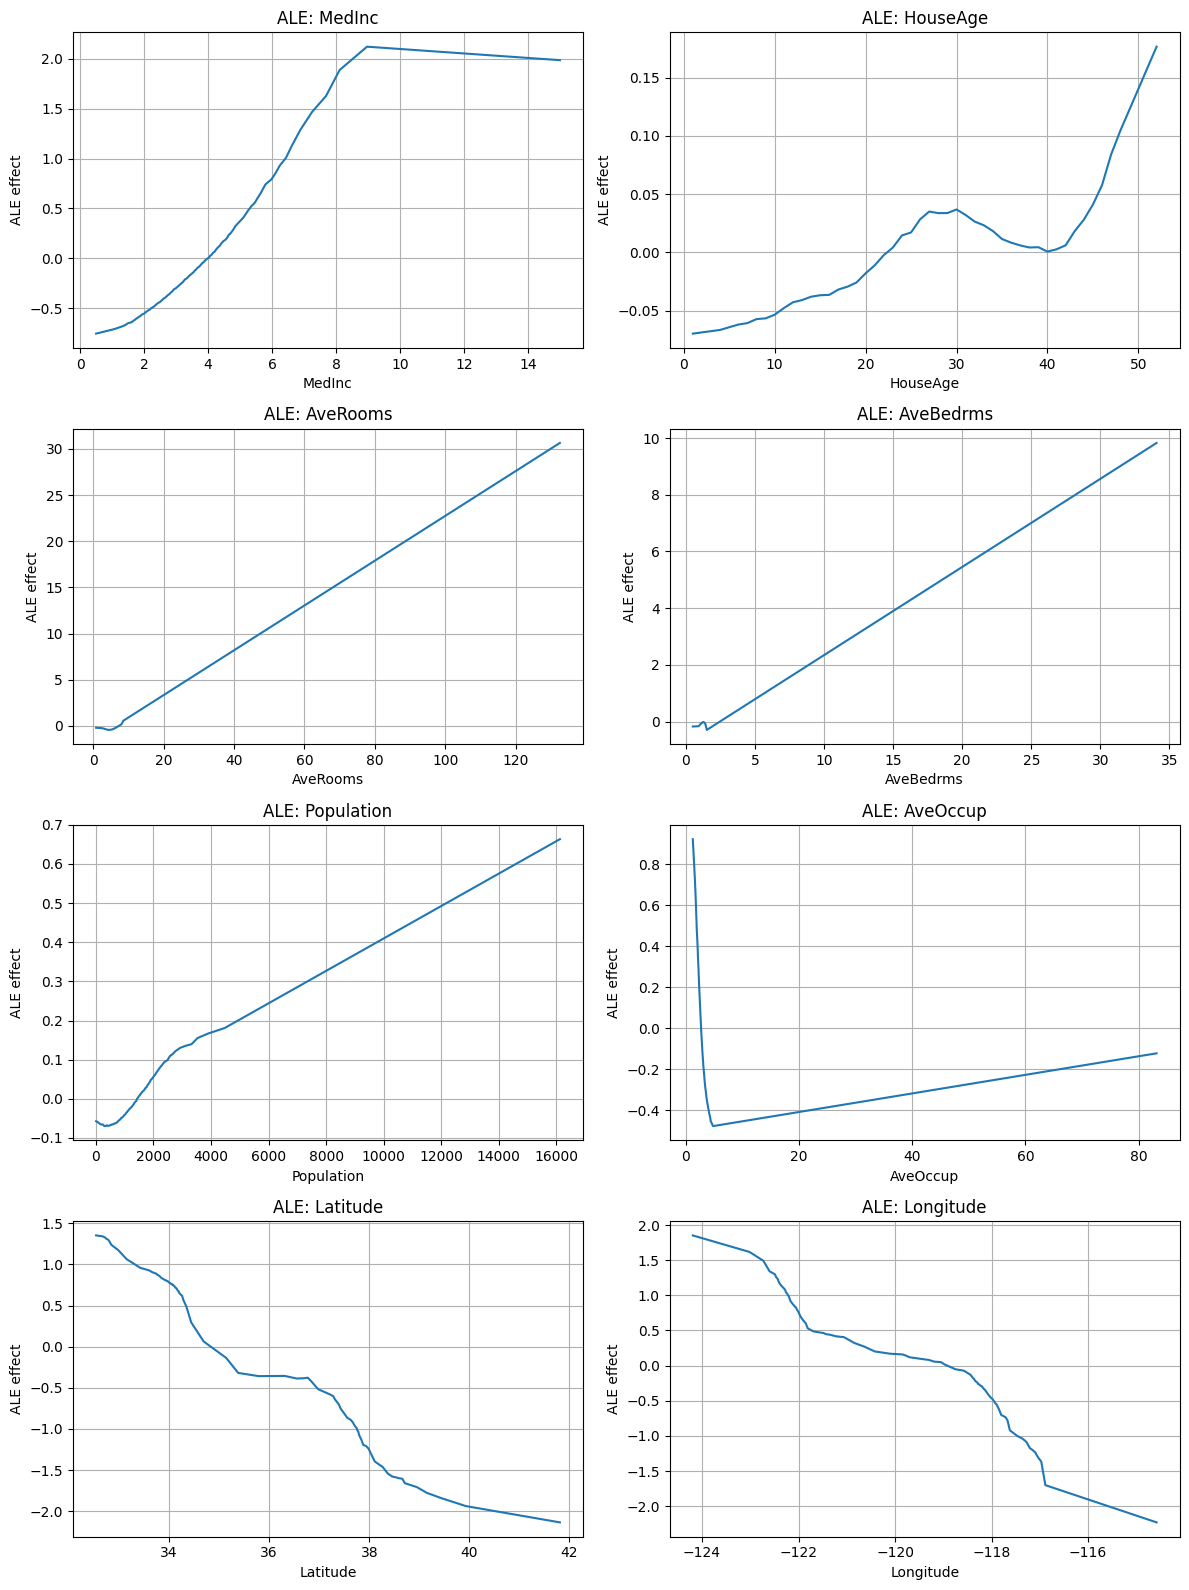

In [ ]:
n_cols = 2
n_rows = (len(feature_names) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for idx, feature_name in enumerate(feature_names):
    ax = axs[idx // n_cols][idx % n_cols]

    # Compute ALE effect
    ale_eff, bin_intervals, _ = ale(
        X=X_test,
        model=pipe,
        feature=feature_name,
        grid_size=100,
        #bin_method="linear",
    )


    intervals = list(bin_intervals.left[:-1]) + [bin_intervals.right[-1]] # For x axis
    #ale_eff = ale_eff[:-1]
    #print(intervals)


    ax.plot(intervals, ale_eff)
    ax.set_title(f"ALE: {feature_name}")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("ALE effect")
    ax.grid(True)

# Turn off any unused axes
for i in range(len(feature_names), n_rows * n_cols):
    axs[i // n_cols][i % n_cols].axis("off")

plt.tight_layout()
plt.savefig("ale.png")
plt.show()

### Study effect of using quantiles vs linear bins

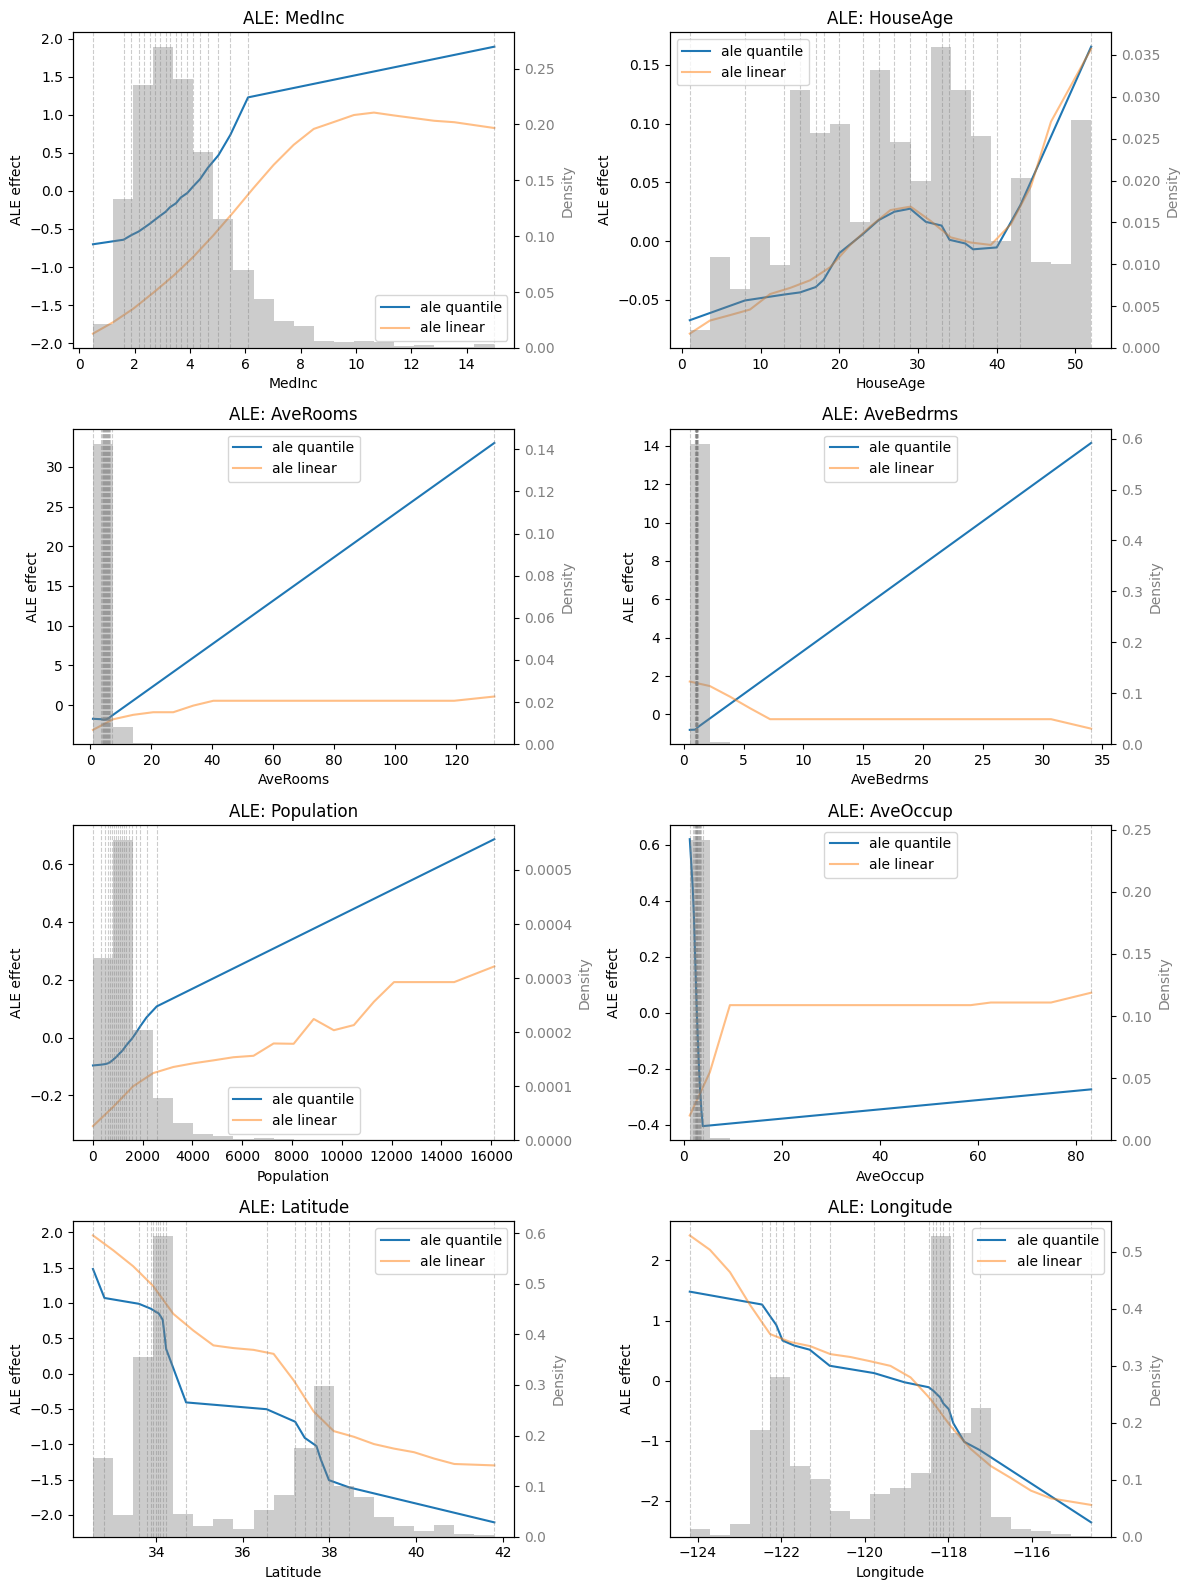

In [ ]:
n_cols = 2
n_rows = -(-len(feature_names) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

ale_effects = {}
ale_effects_linear = {}

ale_intervals = {}
ale_intervals_linear = {}

for idx, feature in enumerate(feature_names):
    ax = axs[idx // n_cols][idx % n_cols]

    # Compute ALE effect
    ale_eff, bin_intervals, delta_mean = ale(
        X=X_test,
        model=pipe,
        feature=feature,
        grid_size=20,
    )
    ale_eff_linear, bin_intervals_linear, delta_mean_linear = ale(
        X=X_test,
        model=pipe,
        feature=feature,
        grid_size=20,
        bin_method="linear",
    )
    ale_eff = ale_eff
    ale_eff_linear = ale_eff_linear
    intervals = list(bin_intervals.left[:-1]) + [bin_intervals.right[-1]] # For x axis labels
    intervals_linear = list(bin_intervals_linear.left[:-1]) + [bin_intervals_linear.right[-1]] # For x axis labels

    ale_effects[feature] = ale_eff
    ale_effects_linear[feature] = ale_eff_linear
    ale_intervals[feature] = intervals
    ale_intervals_linear[feature] = intervals_linear

    interval_widths = list(bin_intervals.right - bin_intervals.left)

    # Manually plot ALE curve on the given axis
    ax.plot(intervals, ale_eff, label="ale quantile")
    ax.plot(intervals_linear, ale_eff_linear, alpha=0.5, label="ale linear")

    # play with this one
    #for xline in intervals_linear:
    for xline in intervals:
        ax.axvline(x=xline, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)

    ax.set_title(f"ALE: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("ALE effect")
    ax.grid(False)
    ax.legend()

    ax_hist = ax.twinx()
    ax_hist.hist(
        X_test[feature],
        bins=20,
        color="gray",
        alpha=0.4,
        density=True,     # so it scales nicely with ALE curve
    )
    ax_hist.set_ylabel("Density", color="gray")
    ax_hist.tick_params(axis='y', labelcolor='gray')

# Turn off any unused axes
for i in range(len(feature_names), n_rows * n_cols):
    axs[i // n_cols][i % n_cols].axis("off")

plt.tight_layout()
plt.savefig("ale.png")
plt.show()

## part3

In [ ]:
import shap

In [ ]:
background = X_train.sample(1000)
explainer = shap.PermutationExplainer(pipe.predict, background)
shap_values = explainer.shap_values(X_test)

PermutationExplainer explainer: 4129it [02:10, 30.38it/s]                          


In [ ]:
type(shap_values)

numpy.ndarray

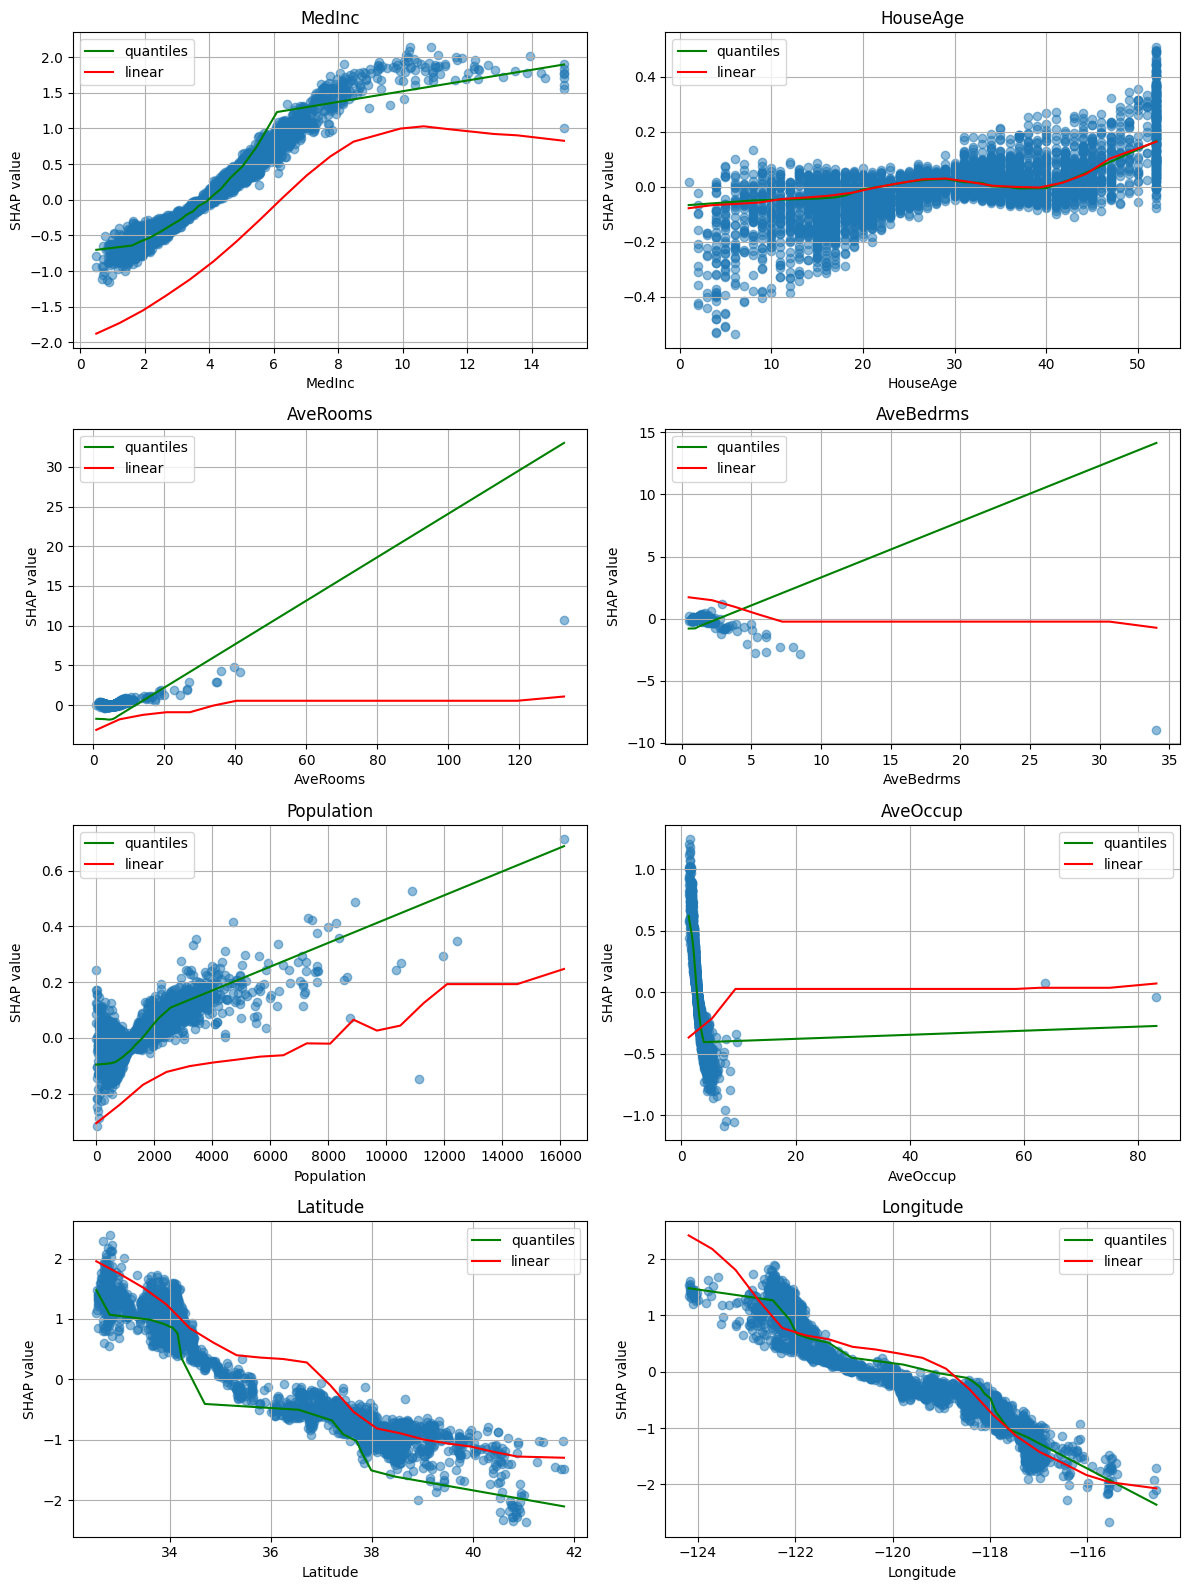

In [ ]:
n_cols = 2
n_rows = -(-len(feature_names) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for idx, feature_name in enumerate(feature_names):
    ax = axs[idx // n_cols][idx % n_cols]

    feature_index = X_test.columns.get_loc(feature_name)
    shap_vals_feature = shap_values[:, feature_index]
    feature_values = X_test[feature_name].values

    ax.plot(ale_intervals[feature_name], ale_effects[feature_name], color="green", label="quantiles")
    ax.plot(ale_intervals_linear[feature_name], ale_effects_linear[feature_name], color="red", label="linear")
    ax.scatter(feature_values, shap_vals_feature, alpha=0.5)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"{feature_name}")
    ax.grid(True)
    ax.legend()

# Turn off any unused axes
for i in range(len(feature_names), n_rows * n_cols):
    axs[i // n_cols][i % n_cols].axis("off")

plt.tight_layout()
plt.show()

The `SHAP` values agree more with the `ALE` values derrived from the `quantiles` defined intervals.

# Homework 2: LOFO/SAGE

In [ ]:
!pip install sage-importance

In [ ]:
import sage

from itertools import combinations
import numpy as np
import pandas as pd
import xgboost
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Data and model

In [ ]:
df = sage.datasets.bike()
features = df.columns.tolist()[:-3]
target = df.columns.tolist()[-1]

In [ ]:
print("Features:", features)
print("Target:", target)

Features: ['Year', 'Month', 'Day', 'Hour', 'Season', 'Holiday', 'Workingday', 'Weather', 'Temp', 'Atemp', 'Humidity', 'Windspeed']
Target: Count


In [ ]:
# Split data, with total count serving as regression target
train, test = train_test_split(df, test_size=int(0.1 * len(df.values)), random_state=123)
train, val = train_test_split(train, test_size=int(0.1 * len(df.values)), random_state=123)

y_train = train[[target]]
y_val = val[[target]]
y_test = test[[target]]
x_train = train[features]
x_val = val[features]
x_test = test[features]

In [ ]:
model = xgboost.XGBRegressor()
model.fit(x_train, y_train);

In [ ]:
def mse(prediction, target):
    return np.mean((prediction - target)**2).item()

In [ ]:
# Calculate performance
base_mse = np.mean((np.mean(y_train) - y_test) ** 2)
full_mse = mse(model.predict(x_test), y_test.to_numpy().flatten())

print("Base rate MSE = {:.2f}".format(base_mse))
print("Model MSE = {:.2f}".format(full_mse))

Base rate MSE = 31591.23
Model MSE = 1878.77


## LOFO

## part 1: Write the lofo function

In [ ]:
def lofo(model, features, train_df, y_train, test_df, y_test, loss):
    losses = {}
    lofos_ratio = {}
    lofos_diff = {}

    for feat in features:# subset of features, removing one feature each time
        _features = list(features)
        _features.remove(feat)
        _x_train = train_df[_features]#
        _x_test = test_df[_features]#

        _model = xgboost.XGBRegressor()
        _model.fit(_x_train, y_train) #

        #get the loss for the subset and store it
        _loss = loss(_model.predict(_x_test), y_test.to_numpy().flatten())
        losses[feat] = _loss



    for feat in features:# each feature in features,
        # calculate the lofo as a ratio or difference (or both)
        lofo = losses[feat]
        lofos_ratio[feat] = lofo/full_mse
        lofos_diff[feat] = lofo - full_mse

    return lofos_ratio, lofos_diff# the lofo(s)


In [ ]:
lofos_ratio, lofos_diff = lofo(model, features, train, y_train, test, y_test, mse)

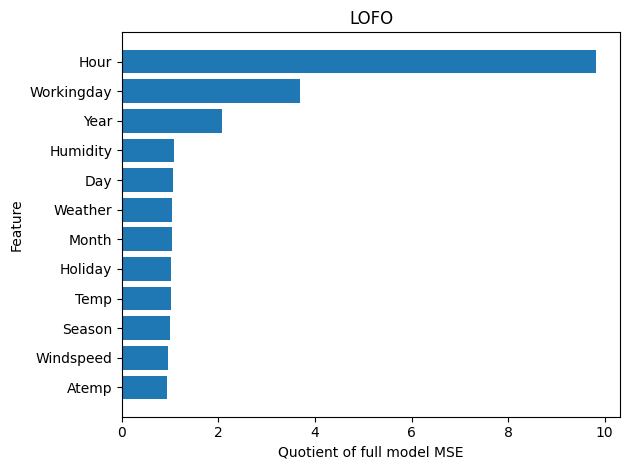

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_ratio.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Quotient of full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

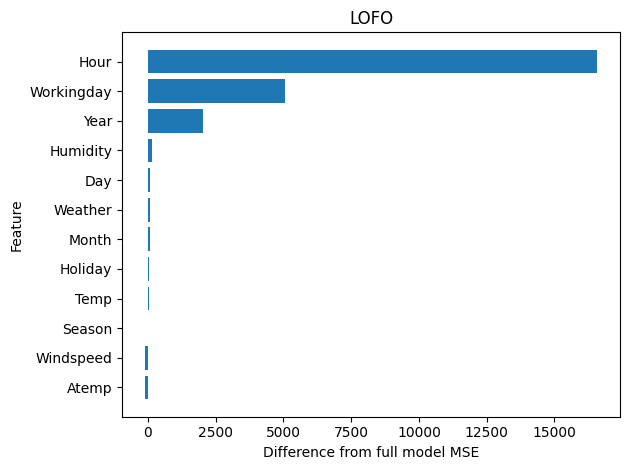

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_diff.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Difference from full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

## studying correlation structure of the dataset

In [ ]:
import seaborn as sns

<Axes: >

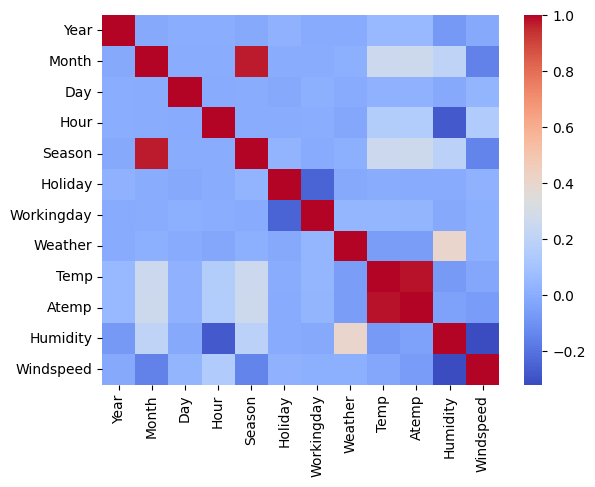

In [ ]:
sns.heatmap(train[features].corr(), cmap='coolwarm')

the features, `Season` and `Month` are highly correlated, and the features `Temp` and `Atemp` are also highly correlated

In [ ]:
import shap

explainer = shap.PermutationExplainer(model.predict, x_train)
shap_values = explainer.shap_values(x_test)
features

PermutationExplainer explainer: 1089it [01:02, 14.77it/s]                          


['Year',
 'Month',
 'Day',
 'Hour',
 'Season',
 'Holiday',
 'Workingday',
 'Weather',
 'Temp',
 'Atemp',
 'Humidity',
 'Windspeed']

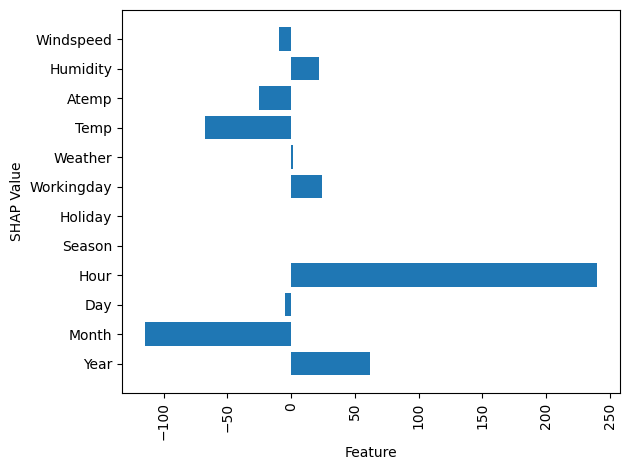

In [ ]:
abs_shaps = np.abs(shap_values[:,1])
data = x_test.copy()
data["shaps"] = abs_shaps
mask = data["shaps"] == abs_shaps.max()
shap_value = shap_values[mask]
plt.barh(features, shap_value[0])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("SHAP Value")
plt.tight_layout()
plt.show()

In [ ]:
!pip install sage-importance

In [ ]:
import sage
import shap

from itertools import combinations
import numpy as np
import pandas as pd
import xgboost
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data and model

In [ ]:
df = sage.datasets.bike()
features = df.columns.tolist()[:-3]
target = df.columns.tolist()[-1]

In [ ]:
print("Features:", features)
print("Target:", target)

Features: ['Year', 'Month', 'Day', 'Hour', 'Season', 'Holiday', 'Workingday', 'Weather', 'Temp', 'Atemp', 'Humidity', 'Windspeed']
Target: Count


In [ ]:
# Split data, with total count serving as regression target
train, test = train_test_split(df, test_size=int(0.1 * len(df.values)), random_state=123)
train, bkg = train_test_split(train, test_size=int(0.1 * len(df.values)), random_state=123)

y_train = train[[target]]
y_bkg = bkg[[target]]
y_test = test[[target]]
x_train = train[features]
x_bkg = bkg[features]
x_test = test[features]

In [ ]:
model = xgboost.XGBRegressor()
model.fit(x_train, y_train);

In [ ]:
# Calculate performance
mean = np.mean(y_train)
base_mse = np.mean((mean - y_test) ** 2)
mse = np.mean((model.predict(x_test) - y_test.to_numpy().flatten())**2)

print("Base rate MSE = {:.2f}".format(base_mse))
print("Model MSE = {:.2f}".format(mse))

Base rate MSE = 31591.23
Model MSE = 1878.77


## SAGE values and plot

In [ ]:
X = x_bkg.to_numpy()          # (N, d)
Y = np.asarray(y_bkg).ravel() # (N,)

imputer = sage.MarginalImputer(model, X[:512])
estimator = sage.PermutationEstimator(imputer, "mse")
sage_values = estimator(X, Y)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print("Number of features:", len(features))
print("Number of SAGE values:", len(sage_values.values))
print(sage_values)

Number of features: 12
Number of SAGE values: 12
SAGE Explanation(
  (Mean): [ 2442.00  1399.18    19.92 18804.12     0.00    38.62  2954.04   214.26
  1720.95   709.20  1191.92   -31.87]
  (Std):  [141.21  89.48  27.05 469.15   0.00  12.39 146.36  46.35  81.34  44.52
  65.63  19.90]
)


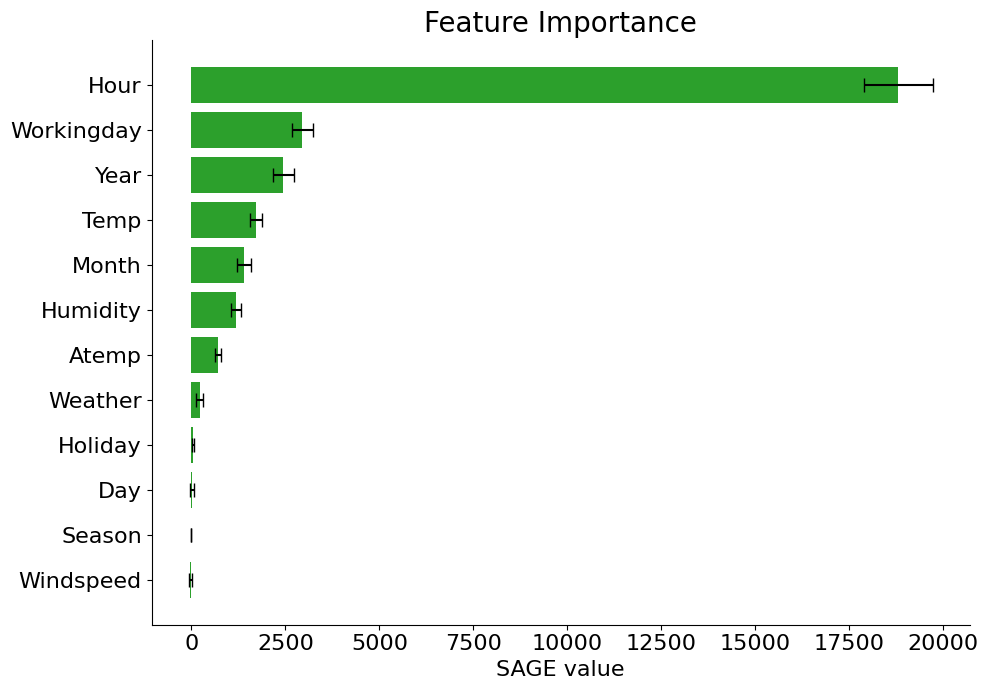

In [ ]:
# Plot results
sage_values.plot(features)

### Imputers and loss functions

In [ ]:
imputer = sage.MarginalImputer(model, X[:512])
imputer

In [ ]:
estimator = sage.PermutationEstimator(imputer, "mse")
estimator.loss_fn

In [ ]:
sage_values = estimator(X, Y)

  0%|          | 0/1 [00:00<?, ?it/s]

## Comparison to SHAP

In [ ]:
explainer = shap.TreeExplainer(model, data=x_bkg)
shap_values = explainer.shap_values(x_test)

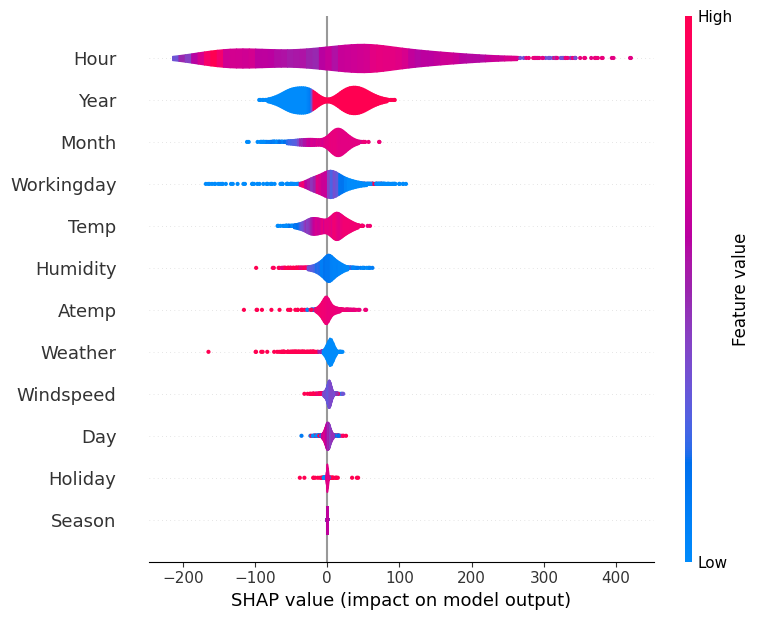

In [ ]:
shap.summary_plot(shap_values, x_test, plot_type="violin")

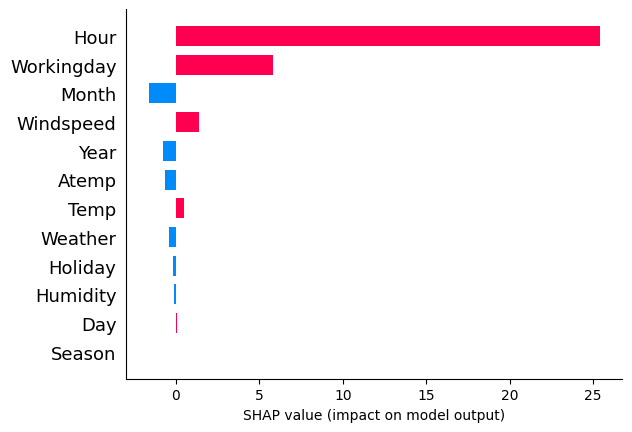

In [ ]:
shap_mean = np.mean(shap_values, axis=0)
shap.bar_plot(shap_mean, feature_names=features, max_display=12)

In [ ]:
df["Year"]

,Year
0,2011
1,2011
2,2011
3,2011
4,2011
...,...
10881,2012
10882,2012
10883,2012
10884,2012


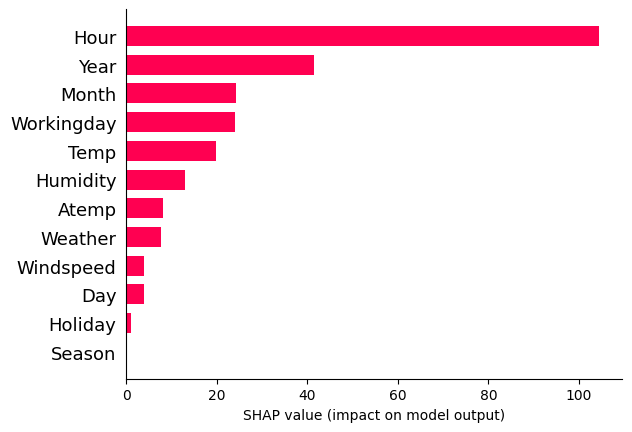

In [ ]:
shap_mean = np.mean(np.abs(shap_values), axis=0)
shap.bar_plot(shap_mean, feature_names=features, max_display=12)

## Comparison to LOFO

In [ ]:
def mse(prediction, target):
    return np.mean((prediction - target)**2).item()

full_mse = mse(model.predict(x_test), y_test.to_numpy().flatten())

def lofo(model, features, train_df, y_train, test_df, y_test, loss):
    losses = {}
    lofos_ratio = {}
    lofos_diff = {}

    for _features in combinations(features, len(features)-1):
        _excluded = list(set(features) - set(_features))[0]
        _features = list(_features)
        _x_train = train_df[_features]
        _x_test = test_df[_features]

        _model = xgboost.XGBRegressor()
        _model.fit(_x_train, y_train);

        _loss = loss(_model.predict(_x_test), y_test.to_numpy().flatten())

        losses[_excluded] = _loss

    for _feature in features:
        lofos_ratio[_feature] = losses[_feature]/full_mse
        lofos_diff[_feature] = losses[_feature]-full_mse

    return lofos_ratio, lofos_diff


In [ ]:
lofos_ratio, lofos_diff = lofo(model, features, train, y_train, test, y_test, mse)

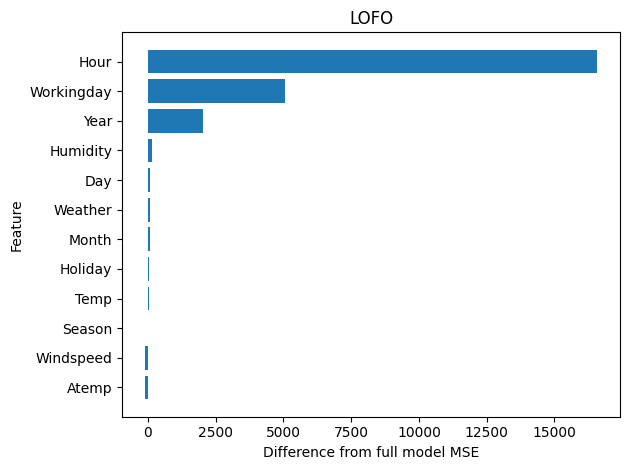

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_diff.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Difference from full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

## Comparison to SHAP and LOFO

In [ ]:
SHAP = shap_mean
SAGE = sage_values.values
LOFOS = [lofos_diff[_feature] for _feature in features]

In [ ]:
def normalize(x):
    x = np.array(x)
    return x / x.sum()

sage_norm = normalize(SAGE)
shap_norm = normalize(SHAP)
lofo_norm = normalize(LOFOS)

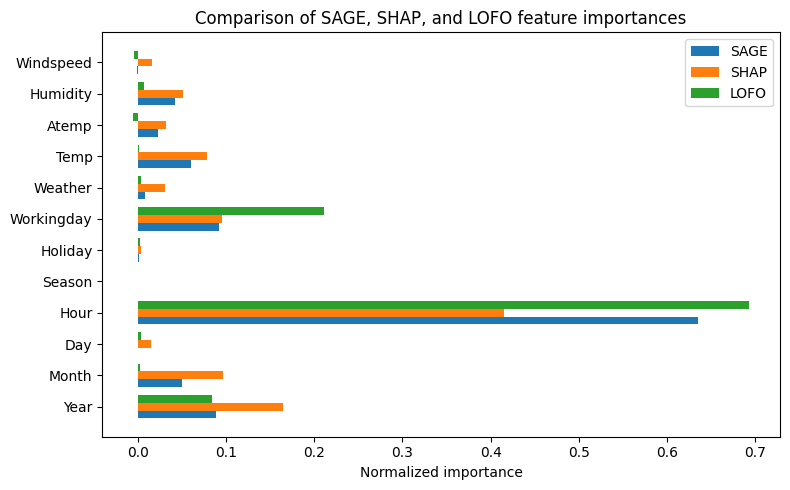

In [ ]:
# Plot grouped bars
x = np.arange(len(features))
width = 0.25

plt.figure(figsize=(8,5))
plt.barh(x - width, sage_norm, width, label='SAGE')
plt.barh(x, shap_norm, width, label='SHAP')
plt.barh(x + width, lofo_norm, width, label='LOFO')

plt.yticks(x, features)
plt.xlabel('Normalized importance')
plt.title('Comparison of SAGE, SHAP, and LOFO feature importances')
plt.legend()
plt.tight_layout()
plt.show()

## Homework part 2: Study correlation structure in the data and investigate a datapoint with SHAP

In [ ]:
feature_list = list(keys)
feature_list.reverse()

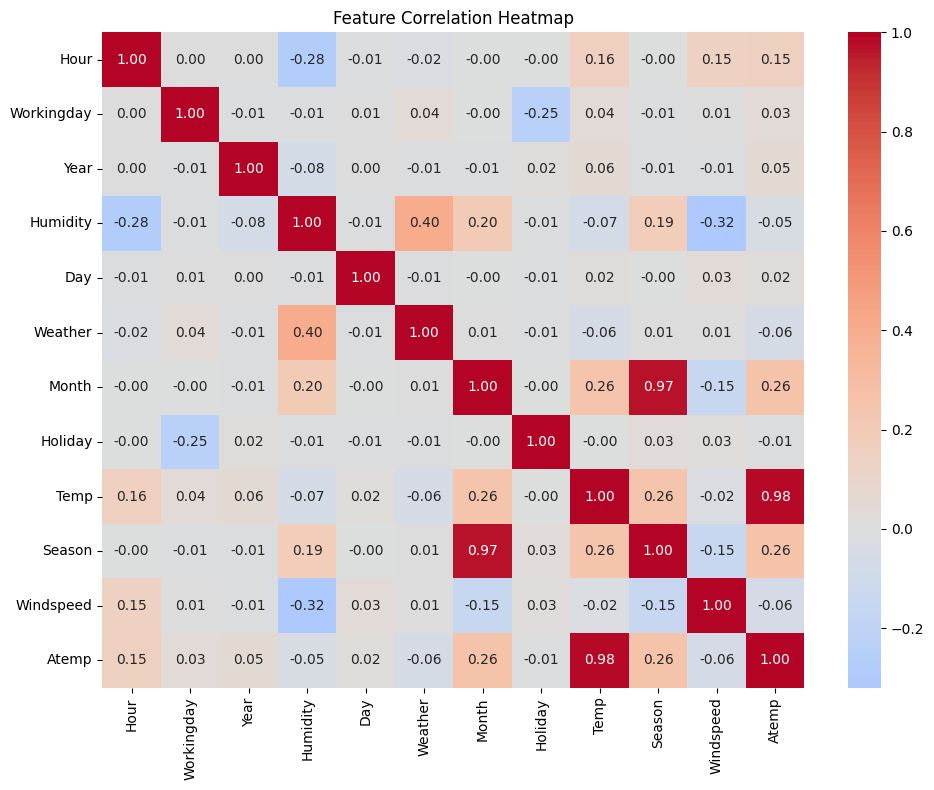

In [ ]:
# Compute correlation matrix
corr = train[feature_list].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

We see that the feature "Month" correlates strongly with Season and Temperature.

Let's find a point for which the SHAP value of Month is high, and look at the SHAP explaination

In [ ]:
interesting = "Month"
f_idx = features.index(interesting)

# shap_values shape: (n_samples, n_features)
abs_shap = np.abs(shap_values[:, f_idx])

# Get top indices and values
top_idx = np.argsort(abs_shap)[::-1][:10]
print("Top samples with high SHAP for", interesting, ":", top_idx)
print("SHAP values:", shap_values[top_idx, f_idx])

Top samples with high SHAP for Month : [ 438  350  450  632  739  691 1031  102  889  917]
SHAP values: [-111.01751961 -108.73147482  -96.36441475  -92.28717958  -92.14128562
  -90.68881544  -90.32328162  -88.71882324  -88.29298175  -87.7180561 ]


In [ ]:
shap.initjs()
index = top_idx[0].item()
shap.force_plot(explainer.expected_value, shap_values[index,:], x_test.iloc[index,:])

12

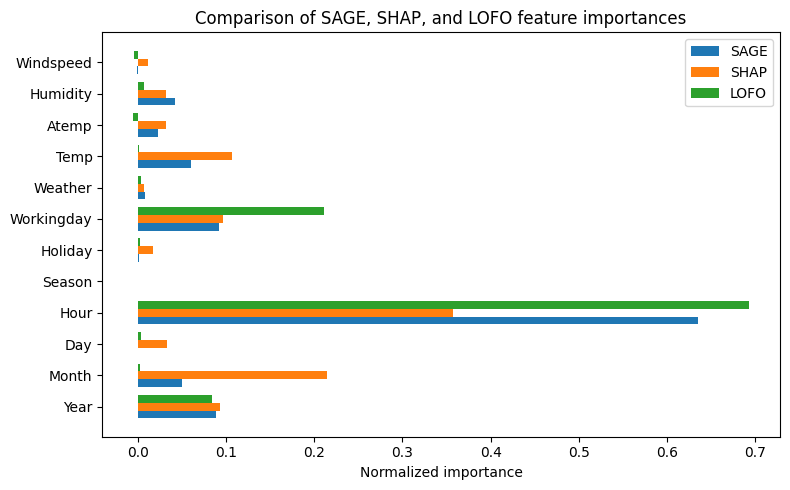

In [ ]:
# Plot grouped bars
x = np.arange(len(features))
width = 0.25
shap_norm = normalize(np.abs(shap_values[index,:]))

plt.figure(figsize=(8,5))
plt.barh(x - width, sage_norm, width, label='SAGE')
plt.barh(x, shap_norm, width, label='SHAP')
plt.barh(x + width, lofo_norm, width, label='LOFO')

plt.yticks(x, features)
plt.xlabel('Normalized importance')
plt.title('Comparison of SAGE, SHAP, and LOFO feature importances for our data point of interest')
plt.legend()
plt.tight_layout()
plt.show()

we notice that `SAGE` and `SHAP` agree for the importance of the feature month, but they disagree with `LOFO`. this is because, the features `Month` and `Season` are correlated, so `LOFO` tends to underestimate their effects and assign them low importances.

# Homework3

In [ ]:
!git clone https://github.com/strumke/AIMS_XAI_Inga.git

fatal: destination path 'AIMS_XAI_Inga' already exists and is not an empty directory.


In [ ]:
import sys
sys.path.append("/content/AIMS_XAI_Inga/CAV")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision.io import read_image
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from PIL import Image

from image_processing import select_concept_images, sample_images, get_resnet_dataloader
from utils import flatten, get_activations, get_grads

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [ ]:
batch_size = 16
num_concept_images = 100
num_target_images = 20
target_class = "zebra"
positive_concept = "striped" #"bubbly"
negative_concept = "dotted"

Download the broden and imagenet data from: TODO

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/imagenet.zip -d /content/data

Archive:  /content/drive/MyDrive/imagenet.zip
   creating: /content/data/imagenet/
  inflating: /content/data/imagenet/n02391049_2.jpg  
  inflating: /content/data/imagenet/n02391049_254.JPEG  
  inflating: /content/data/imagenet/volcano_zebra.jpg  
   creating: /content/data/imagenet/zebra/
  inflating: /content/data/imagenet/zebra/n02391049_10007.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10027.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_1004.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10047.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10063.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_101.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_1012.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10122.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10123.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10129.jpg  
  inflating: /content/data/imagenet/zebra/n02391049_10131.jpg  
  infla

In [ ]:
!cp -r /content/data/broden/* /content/AIMS_XAI_Inga/data/broden/
!cp -r /content/data/imagenet/* /content/AIMS_XAI_Inga/data/imagenet/

In [ ]:
!cp -r /content/data/broden/dtd /content/AIMS_XAI_Inga/data/broden/

In [ ]:
# Get the absolute path to concept and target images
base_dir ="/content/AIMS_XAI_Inga"# os.path.join(os.getcwd(), '../')
concept_folder = os.path.join(base_dir, 'data', 'broden', 'dtd')
target_folder = os.path.join(base_dir, 'data', 'imagenet', target_class)

p_concept_paths = select_concept_images(folder_path=concept_folder, concept=positive_concept, n=num_concept_images)
n_concept_paths = select_concept_images(folder_path=concept_folder, concept=negative_concept, n=num_concept_images)

target_paths = sample_images(folder_path=target_folder, n=num_target_images)

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
resnet.eval();

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


In [ ]:
class_idx = ResNet18_Weights.IMAGENET1K_V1.meta["categories"].index(target_class)

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224)),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

positive_loader = get_resnet_dataloader(p_concept_paths, transform, batch_size=batch_size)
negative_loader = get_resnet_dataloader(n_concept_paths, transform, batch_size=batch_size)
target_loader = get_resnet_dataloader(target_paths, transform, batch_size=batch_size)

## Interlude: Look at data and layer

In [ ]:
def look_at(image):
    img = (image - image.min()) / (image.max() - image.min())
    plt.imshow(img.permute(1, 2, 0))
    plt.show()

torch.Size([3, 224, 224])


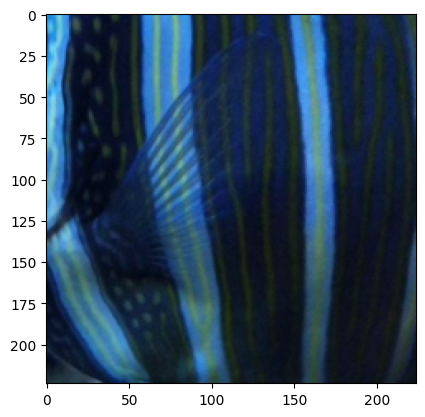

In [ ]:
pos_image = next(iter(positive_loader))[7]
print(pos_image.shape)
look_at(pos_image)

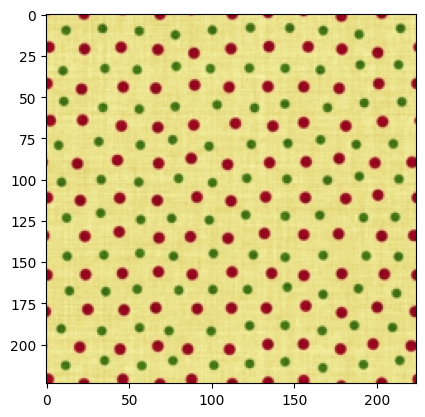

In [ ]:
neg_image = next(iter(negative_loader))[7]
look_at(neg_image)

In [ ]:
layer = resnet.layer4[0]
layer._modules

{'conv1': Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False),
 'bn1': BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 'relu': ReLU(inplace=True),
 'conv2': Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False),
 'bn2': BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 'downsample': Sequential(
   (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
   (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 )}

## Get activations manually

In [ ]:
activations = {}
# keys = layer names (strings)
# values = activation tensors

def get_activation(name):
    # function factory for creating a hook function that captures the name of the layer it’s attached to.
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

layer_name = 'layer4'
handle = dict(resnet.named_modules())[layer_name].register_forward_hook(get_activation(layer_name))


_ = resnet(pos_image.unsqueeze(0).to(device))

handle.remove()

print(activations["layer4"].shape)

torch.Size([1, 512, 7, 7])


In [ ]:
acts = activations["layer4"]
acts.view(acts.size(0), -1).numpy().shape

(1, 25088)

## Make the CAV

In [ ]:
def train_cav(positive_activations, negative_activations, seed=1337):

    X = np.concatenate([positive_activations, negative_activations], axis=0)
    y = np.concatenate([np.ones(len(positive_activations)), np.zeros(len(negative_activations))])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=seed)
    #X_train, y_train = shuffle(X, y, random_state=seed)
    classifier = LogisticRegression(random_state=seed, max_iter=1000)
    classifier.fit(X_train, y_train)

    accuracy = classifier.score(X_test, y_test)
    print("Probe accuracy:", accuracy)

    cav = classifier.coef_[0]
    unit_cav = cav / np.linalg.norm(cav)

    return unit_cav

In [ ]:
layer = resnet.layer4[0]

In [ ]:
positive_activations = flatten(get_activations(resnet, positive_loader, device, layer))
negative_activations = flatten(get_activations(resnet, negative_loader, device, layer))

In [ ]:
stripes_cav = train_cav(positive_activations, negative_activations)
#bubbly_cav = train_cav(positive_activations, negative_activations)

Probe accuracy: 1.0


In [ ]:
print(stripes_cav.shape)
print(stripes_cav)

(25088,)
[-0.00197389 -0.01441728 -0.01102986 ...  0.00241429  0.00346734
  0.00928773]


## ... and calculate TCAV scores

In imagenet, zebra is class 340

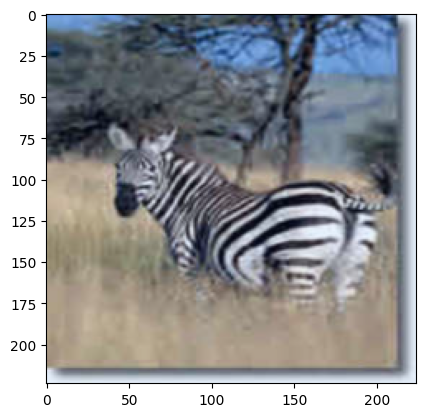

In [ ]:
image = next(iter(target_loader))[5]
look_at(image)

In [ ]:
def make_gradient_hook(grads):
    def bwd_hook(module, grad_input, grad_output):
        grad = grad_output[0]
        grads.append(grad.squeeze(0).detach().cpu())
    return bwd_hook

resnet.eval()
sample_input = image.unsqueeze(0).to(device)

grads = []
hook = layer.register_full_backward_hook(make_gradient_hook(grads))

resnet.zero_grad()
output = resnet(sample_input)
logits = output[0]

logit = logits[340]
logit.backward()
hook.remove()

print("Number of gradients from layer:", len(grads[0]))

Number of gradients from layer: 512


In [ ]:
def tcav(cav, grads):

    directional_derivatives = np.dot(grads, cav)
    positive_counts = np.sum(directional_derivatives > 0)
    tcav_score = positive_counts / directional_derivatives.shape[0]

    return tcav_score

In [ ]:
grads = flatten(get_grads(resnet, target_loader, device, layer, target_idx=340))
tcav_score = tcav(stripes_cav, grads)
#tcav_score = tcav(bubbly_cav, grads)
print(f"TCAV score: {tcav_score}")

TCAV score: 1.0


## part1: Plot the probe accuracy per layer of the model.

First, modify the train_cav function to return probe accuracy.

In [ ]:
def train_cav(positive_activations, negative_activations, seed=1337):

    X = np.concatenate([positive_activations, negative_activations], axis=0)
    y = np.concatenate([np.ones(len(positive_activations)), np.zeros(len(negative_activations))])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=seed)
    #X_train, y_train = shuffle(X, y, random_state=seed)
    classifier = LogisticRegression(random_state=seed, max_iter=1000)
    classifier.fit(X_train, y_train)

    accuracy = classifier.score(X_test, y_test)

    cav = classifier.coef_[0]
    unit_cav = cav / np.linalg.norm(cav)

    return unit_cav, accuracy

Loop through model to get a list of all layers

In [ ]:
names, layers = [], []
for name, layer in resnet.named_children():
    names.append(name)
    layers.append(layer)
print("Number of layers:" , len(layers))

Number of layers: 10


In [ ]:
names

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

Get probe accuracies for each layer and plot

In [ ]:
accuracies = []
for _layer in layers:
    _positive_activations = flatten(get_activations(resnet, positive_loader, device, _layer))
    _negative_activations = flatten(get_activations(resnet, negative_loader, device, _layer))
    _, _accuracy = train_cav(_positive_activations, _negative_activations)
    accuracies.append(_accuracy)

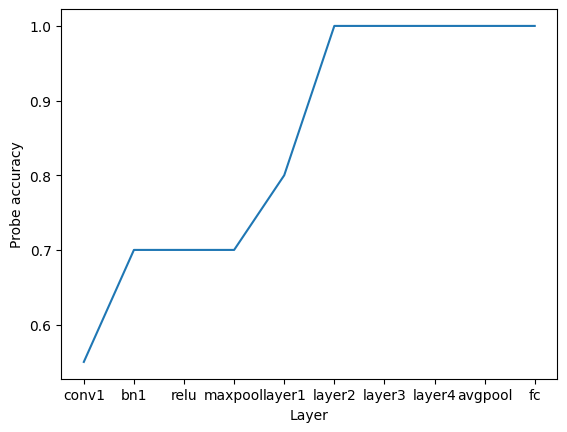

In [ ]:
colors = plt.cm.tab10(range(len(accuracies)))
plt.plot(range(len(accuracies)), accuracies)
plt.xticks(range(len(names)), names)
plt.xlabel('Layer')
plt.ylabel('Probe accuracy')
plt.show()

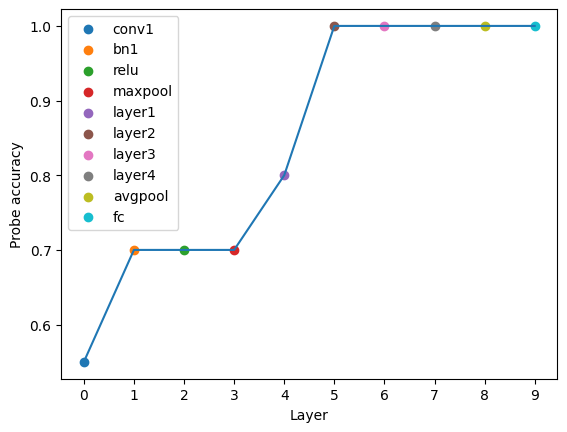

In [ ]:
colors = plt.cm.tab10(range(len(accuracies)))
for _i, _acc in enumerate(accuracies):
    plt.scatter(_i, _acc, color=colors[_i], label=names[_i])
plt.plot(range(len(accuracies)), accuracies)
plt.xticks(range(len(names)), range(len(names)))
plt.xlabel('Layer')
plt.ylabel('Probe accuracy')
plt.legend()
plt.show()

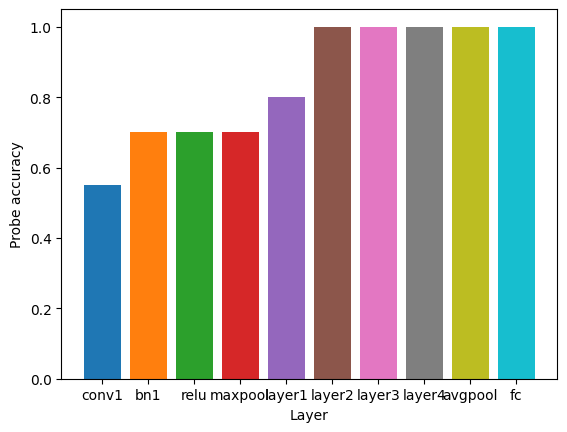

In [ ]:
colors = plt.cm.tab10(range(len(accuracies)))
plt.bar(range(len(accuracies)), accuracies, color=colors)
plt.xticks(range(len(names)), names)
plt.xlabel('Layer')
plt.ylabel('Probe accuracy')
plt.show()

We can also select the layers more carefully

In [ ]:
probe_layers = [resnet.conv1, resnet.layer1[0], resnet.layer2[0], resnet.layer3[0], resnet.layer4[0], resnet.fc]
probe_names = [names[0], names[4], names[5], names[6], names[7], names[9]]

In [ ]:
accuracies = []
for _layer in probe_layers:
    _positive_activations = flatten(get_activations(resnet, positive_loader, device, _layer))
    _negative_activations = flatten(get_activations(resnet, negative_loader, device, _layer))
    _, _accuracy = train_cav(_positive_activations, _negative_activations)
    accuracies.append(_accuracy)

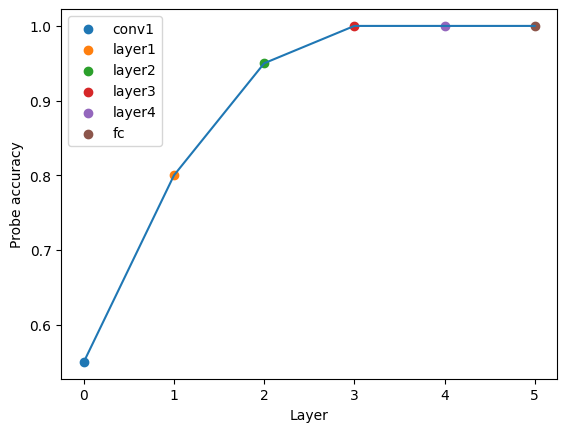

In [ ]:
colors = plt.cm.tab10(range(len(accuracies)))
for _i, _acc in enumerate(accuracies):
    plt.scatter(_i, _acc, color=colors[_i], label=probe_names[_i])
plt.plot(range(len(accuracies)), accuracies)
plt.xticks(range(len(probe_names)), range(len(probe_names)))
plt.xlabel('Layer')
plt.ylabel('Probe accuracy')
plt.legend()
plt.show()

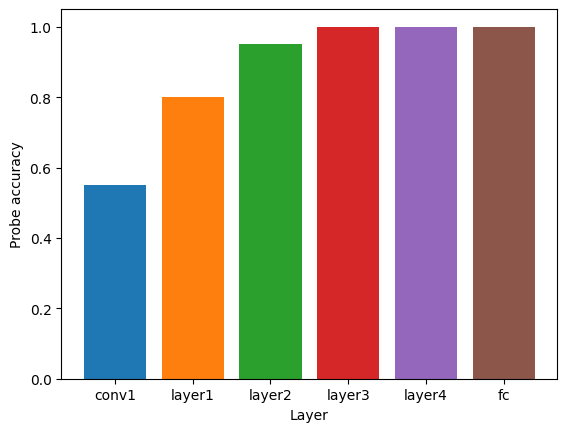

In [ ]:
colors = plt.cm.tab10(range(len(accuracies)))
plt.bar(range(len(accuracies)), accuracies, color=colors)
plt.xticks(range(len(probe_names)), probe_names)
plt.xlabel('Layer')
plt.ylabel('Probe accuracy')
plt.show()

##Part 2: Compare the stripes CAV to the activations in the corresponding layer, for the difficult image

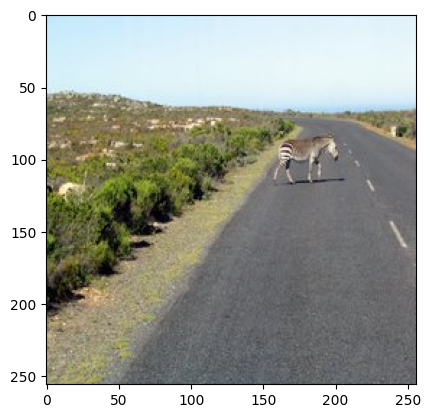

In [ ]:
filepath="/content/AIMS_XAI_Inga/data/imagenet/volcano_zebra.jpg"
img = Image.open(filepath).convert('RGB')
plt.imshow(img)
img_tensor = transform(img)

In [ ]:
resnet.eval();
resnet(img_tensor.unsqueeze(0).to(device)).argmax()

tensor(980)

In [ ]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

layer_name = 'layer4'
handle = dict(resnet.named_modules())[layer_name].register_forward_hook(get_activation(layer_name))

_ = resnet(img_tensor.unsqueeze(0).to(device))

handle.remove()
mystery_activations = activations["layer4"].flatten()

In [ ]:
print("Activation vector shape:", mystery_activations.shape)
print("Stripes CAV shape:", stripes_cav.shape)

Activation vector shape: torch.Size([25088])
Stripes CAV shape: (25088,)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

A cosine similarity score of 1 means that two vectors are identical, 0 means they are orthogonal (unrelated), and -1 means they are diametrically opposed.

In [ ]:
cosine_similarity(mystery_activations.reshape(1, -1), stripes_cav.reshape(1, -1))

array([[0.0372705]])

The cosine similarity is very low.
that means that, our activations for the image in that layer do not contains enought components from the CAV vector representing the concept of stripe. since our TCAV score was high for that concept, this could explain why our model thinks that the image is not a zebra.

# Homework 4

In [ ]:
!pip install transformers

In [ ]:
!git clone https://github.com/strumke/AIMS_XAI_Inga.git

Cloning into 'AIMS_XAI_Inga'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 132 (delta 21), reused 23 (delta 15), pack-reused 103 (from 1)
Receiving objects: 100% (132/132), 48.46 MiB | 9.24 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Updating files: 100% (46/46), done.


In [ ]:
import sys
sys.path.append('/content/AIMS_XAI_Inga/Transformers')

In [ ]:
# pip install transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import ViTImageProcessor, ViTForImageClassification
import torch
import torch.nn.functional as F
import shap

import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from utils import tokenize_input, plot_attention_weights, get_model_pred
#from grad_sam import grad_sam
#from shap_values import shap_values
from tcav import select_concept_images, sample_images, get_vit_dataloader, flatten, get_activations, get_grads, train_cav, tcav

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

seed = 1337
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

Using device cpu


In [ ]:
# Use BERT trained on the SST-2 dataset (for binary classification)
tokenizer = AutoTokenizer.from_pretrained("textattack/bert-base-uncased-SST-2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
print("Starting model loading...")
model = AutoModelForSequenceClassification.from_pretrained("textattack/bert-base-uncased-SST-2",attn_implementation="eager").to(device)
print("Model loading complete.")

Starting model loading...


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Model loading complete.


In [ ]:
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## Grad-SAM

In [ ]:
def display_token_importance(tokens, importance):
    sorted_ = sorted(list(zip(tokens, importance)), key=lambda x: x[1], reverse=True)

    for i, (token, value) in enumerate(sorted_, start=1):
        print(f"{i}. '{token}': {value:.8f}")

def plot_token_importance(tokens, scores, title="Token importance (Grad-CAM)"):
    scores = scores - scores.min()
    if scores.max() > 0:
        scores = scores / scores.max()

    fig, ax = plt.subplots(figsize=(len(tokens) * 0.7, 2))

    ax.imshow(scores[np.newaxis, :], aspect="auto", cmap="Reds")
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticks([])
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [ ]:
def get_grads_gradsam(model, attentions, logits):
    """Return the gradient of the output with respect to the attention weights for all heads in all layers."""

    n_layers = model.config.num_hidden_layers

    pred = get_model_pred(logits)
    logits = logits.squeeze()

    attention_grads = {layer_idx : None for layer_idx in range(n_layers)}

    # Retain gradients for attention matrices
    for att in attentions:
        att.retain_grad()

    model.zero_grad()

    # Backward from the model prediction
    logits[pred].backward(retain_graph=True)

    # Collect gradients for each layer
    for layer_idx, att in enumerate(attentions):
        grad = att.grad.squeeze().clone() # Shape (n_heads, seq_len, seq_len)
        attention_grads[layer_idx] = grad

    return attention_grads

### Homework: Write the Grad-SAM function

In [ ]:
def grad_sam(model, attentions, logits):
    """Returns the Grad-SAM score for all tokens in an input sequence."""

    model = model.to(device)

    n_heads = model.config.num_attention_heads # number of attention heads
    n_layers = model.config.num_hidden_layers # number of hidden layers

    attention_grads = get_grads_gradsam(model, attentions, logits)

    seq_len = attentions[0].size(-1)# find sequence length from attentions, including CLS and SEP tokens are included

    layer_vectors = []

    for layer_idx, grad in attention_grads.items():
        relu_grad = F.relu(grad.to(device)) # take the relu of the gradient # Shape (n_heads, seq_len, seq_len)

        attention = attentions[layer_idx].squeeze().clone().to(device)# get attentions for the layer # Shape (n_heads, seq_len, seq_len)

        hadamard_product = attention*relu_grad # do the multiplication from the equation

        summed_columns = hadamard_product.sum(dim=-1, keepdim=False) # Sum attention weights for each head (sum over columns) # Shape (n_heads, seq_len)

        summed_heads = summed_columns.sum(dim=0, keepdim=False)# Sum over all heads # Shape (seq_len)

        # append summed_heads to the layer_vectors
        layer_vectors.append(summed_heads)

    grad_sam_scores = sum(layer_vectors) # sum over the layer_vectors
    grad_sam_scores = grad_sam_scores / (n_layers*n_heads*seq_len)# normalise

    return grad_sam_scores

In [ ]:
sentences = ["I like the movie",
            "She hates the book",
            "This is so boring",
            "I cannot wait for next time",
            "You look extremely confused"
            ]

for sentence in sentences:
    # Return the tokenizer output for the input sentence, which includes the tokenized sentences with
    # added CLS and SEP tokens and the attention masks
    input = tokenize_input(tokenizer, sentence).to(device)
    output = model(**input, output_attentions=True) # Forward pass
    logits = output.logits
    pred = get_model_pred(logits)

    # Get attention matrices for all heads and layers
    attentions = output.attentions
    # attentions is a tuple with tensor elements of shape
    # (batch size, num attention heads, sequence length, sequence length),
    # one tensor per layer (i.e., encoder block)
    print(f"The sentiment of '{sentence}' is {pred}")

The sentiment of 'I like the movie' is 1
The sentiment of 'She hates the book' is 0
The sentiment of 'This is so boring' is 0
The sentiment of 'I cannot wait for next time' is 1
The sentiment of 'You look extremely confused' is 0


In [ ]:
grad_sam_scores = grad_sam(model, attentions, logits).detach().cpu().numpy()

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(input["input_ids"][0])
display_token_importance(tokens, grad_sam_scores)

1. '[CLS]': 0.00099815
2. 'confused': 0.00080487
3. 'you': 0.00054431
4. 'look': 0.00051781
5. 'extremely': 0.00039444
6. '[SEP]': 0.00013036


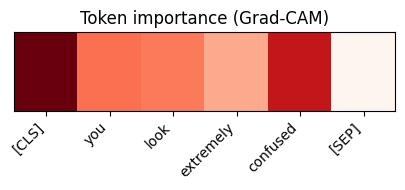

In [ ]:
plot_token_importance(tokens, grad_sam_scores)

## SHAP

In [ ]:
"""Implementation following https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/text.html"""

def f(x):
    # Tokenize all strings in input
    tv = torch.tensor([tokenizer(v, truncation=True,
                                 max_length=tokenizer.model_max_length,
                                 padding="max_length")["input_ids"] for v in x], device=device)

    # Fix padding stuff when input consist of several sentences
    attention_masks = torch.tensor([tokenizer(v, truncation=True, max_length=tokenizer.model_max_length,
                                              padding="max_length")["attention_mask"] for v in x], device=device)

    # Get model prediction (logits) and return the positive class
    outputs = model(input_ids=tv, attention_mask=attention_masks)[0].detach().cpu().numpy()

    return np.array(outputs[:,1]) # Positive class logits

Attention masks isn't necessary when the input is one sentence.

When the input contains several sentences of different lengst, padding tokens must be added.

Attention masks masks out padding tokens when calculating attention scores, so that only the actual input sentence is used.

In [ ]:
f(sentences)

array([ 3.6635602, -3.145779 , -3.4217703,  2.665551 , -2.903021 ],
      dtype=float32)

In [ ]:
explainer = shap.Explainer(f, tokenizer)
shap_values = explainer(sentences, fixed_context=1)

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [01:13<00:29, 14.75s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 4/5 [01:38<00:18, 18.97s/it]

  0%|          | 0/56 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [02:08<00:00, 22.83s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [02:32, 30.54s/it]


In [ ]:
shap_values

.values =
array([array([-0.12959369,  0.5697345 ,  2.80113624, -0.14384766,  0.32744562,
               0.17642224])                                                   ,
       array([ 0.04401791,  0.04553521, -3.53780533, -0.05805473,  0.00513335,
               0.29313202])                                                   ,
       array([ 0.30843858,  0.25726203,  0.28962771,  0.28991643, -4.94576707,
               0.31648932])                                                   ,
       array([-0.10001777,  0.30019118,  1.070114  ,  1.28322409,  0.11099617,
               0.42984835,  0.22122888, -0.22297736])                         ,
       array([ 0.59630467,  0.48589803,  0.2785715 , -0.05426274, -4.83737086,
               0.56557562])                                                   ],
      dtype=object)

.base_values =
array([ 0.06226267,  0.06226267,  0.06226267, -0.42705658,  0.06226267])

.data =
(array(['', 'I ', 'like ', 'the ', 'movie', ''], dtype=object), array(['', '

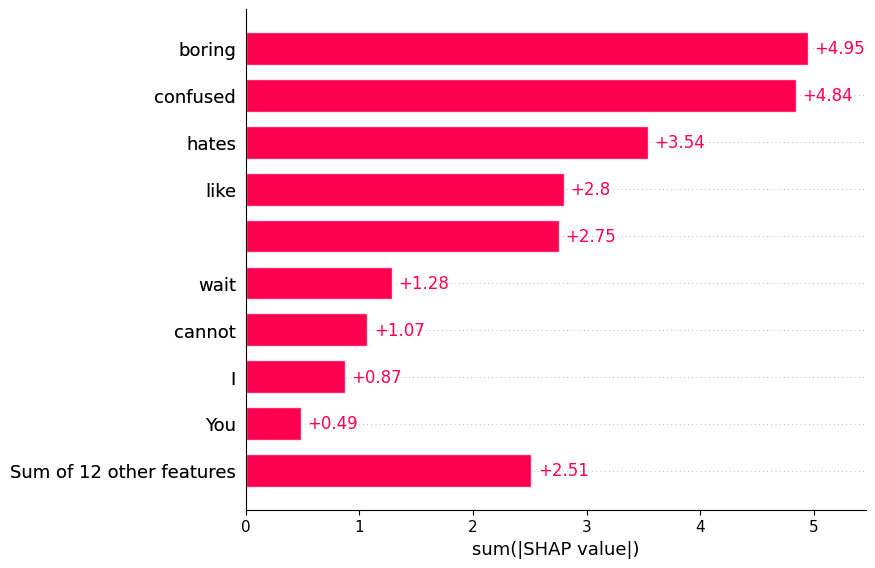

In [ ]:
shap.plots.bar(shap_values.abs.sum(0))

In [ ]:
i = 3
shap.plots.initjs()
shap.plots.text(shap_values[i])

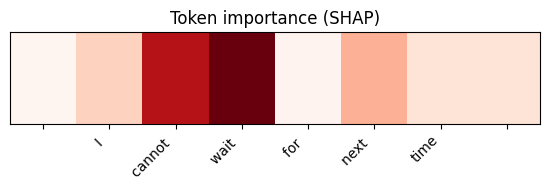

In [ ]:
plot_token_importance(shap_values[i].data, np.abs(shap_values[i].values), title="Token importance (SHAP)")

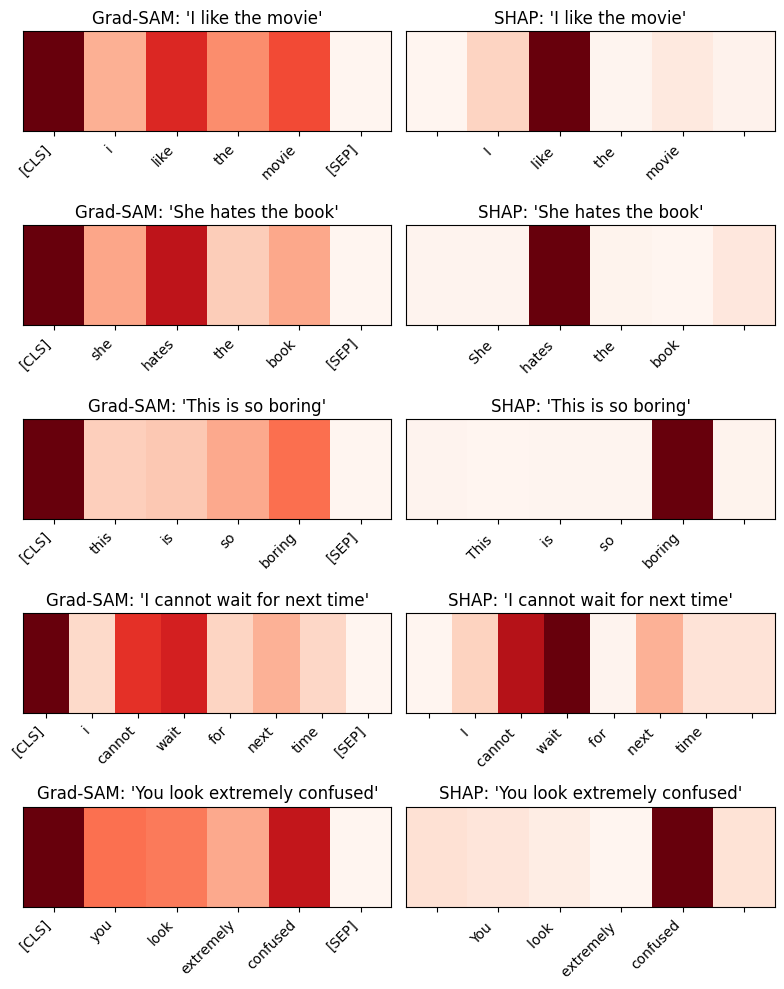

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_sentences = len(sentences)
fig, axes = plt.subplots(num_sentences, 2, figsize=(8, num_sentences * 2))

# Ensure axes is always 2D, even for a single sentence
if num_sentences == 1:
    axes = np.expand_dims(axes, axis=0)

for i, sentence in enumerate(sentences):
    # Grad-SAM calculations
    input_ids_dict = tokenize_input(tokenizer, sentence)
    input_on_device = {k: v.to(device) for k, v in input_ids_dict.items()}
    output = model(**input_on_device, output_attentions=True)
    logits = output.logits
    attentions = output.attentions
    current_grad_sam_scores = grad_sam(model, attentions, logits).detach().cpu().numpy()
    current_grad_sam_tokens = tokenizer.convert_ids_to_tokens(input_ids_dict["input_ids"][0])

    # SHAP values extraction
    current_shap_values = shap_values[i]
    current_shap_tokens = current_shap_values.data # SHAP tokens are already strings
    current_shap_importance = np.abs(current_shap_values.values)

    # Plotting Grad-SAM
    ax_grad_sam = axes[i, 0]
    scores_grad_sam = current_grad_sam_scores - current_grad_sam_scores.min()
    if scores_grad_sam.max() > 0:
        scores_grad_sam = scores_grad_sam / scores_grad_sam.max()

    ax_grad_sam.imshow(scores_grad_sam[np.newaxis, :], aspect="auto", cmap="Reds")
    ax_grad_sam.set_xticks(np.arange(len(current_grad_sam_tokens)))
    ax_grad_sam.set_xticklabels(current_grad_sam_tokens, rotation=45, ha="right")
    ax_grad_sam.set_yticks([])
    ax_grad_sam.set_title(f"Grad-SAM: '{sentence}'")

    # Plotting SHAP
    ax_shap = axes[i, 1]
    scores_shap = current_shap_importance - current_shap_importance.min()
    if scores_shap.max() > 0:
        scores_shap = scores_shap / scores_shap.max()

    ax_shap.imshow(scores_shap[np.newaxis, :], aspect="auto", cmap="Reds")
    ax_shap.set_xticks(np.arange(len(current_shap_tokens)))
    ax_shap.set_xticklabels(current_shap_tokens, rotation=45, ha="right")
    ax_shap.set_yticks([])
    ax_shap.set_title(f"SHAP: '{sentence}'")

plt.tight_layout()
plt.show()

The `Grad-SAM` and the `SHAP` feature importances differs, mainly on the importance of the `[CLS]` token.

this could be because they measure different things. the first one measure the sensivity of the model output to the attentions of the token, while the other measure the contribution of the token to the deviation of the output of the model from a base value.

Also, the `[CLS]` token has a hight `Grad-SAM` score because the model is trained specialy to gather all the informations of the sequence into the activations related to that token.

the importance of that token is low for the `SHAP` method because the tokenizer alway add that token for every input. that means, that when sampling, `SHAP` will always feed to the model  tokenized inputs with that token, and then, it acts like a player that contribute nothing to the coalition.

## ploting the attentions

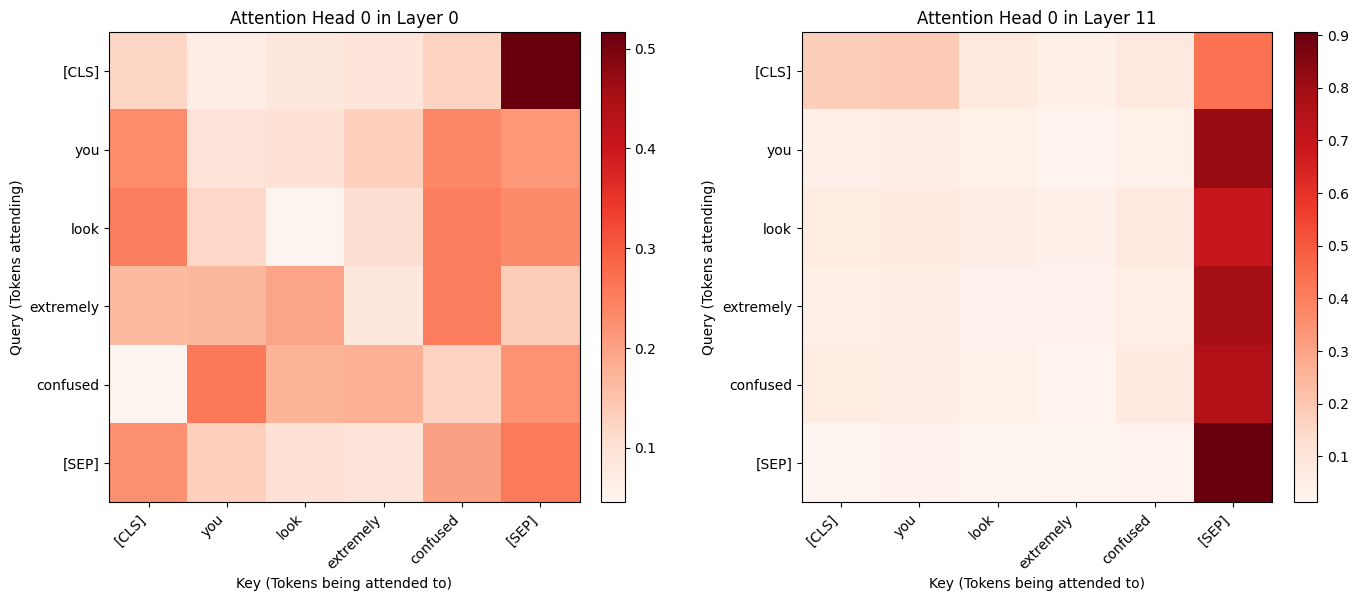

In [ ]:
sentence_to_analyze = "You look extremely confused"
input_ids_dict = tokenize_input(tokenizer, sentence_to_analyze)
input_on_device = {k: v.to(device) for k, v in input_ids_dict.items()}
output = model(**input_on_device, output_attentions=True)
all_attentions = output.attentions
tokens_to_plot = tokenizer.convert_ids_to_tokens(input_ids_dict["input_ids"][0])

selected_layers = [0, model.config.num_hidden_layers - 1] # First and last layer
selected_head = 0 # Choose the first head for simplicity

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, layer_idx in enumerate(selected_layers):
    # Extract attention weights for the selected layer and head
    # Shape: (batch_size, num_heads, seq_len, seq_len)
    attention_weights = all_attentions[layer_idx][0, selected_head].detach().cpu().numpy()

    # Plot the heatmap
    im = axes[i].imshow(attention_weights, cmap='Reds')
    axes[i].set_xticks(np.arange(len(tokens_to_plot)))
    axes[i].set_yticks(np.arange(len(tokens_to_plot)))
    axes[i].set_xticklabels(tokens_to_plot, rotation=50, ha="right")
    axes[i].set_yticklabels(tokens_to_plot)
    axes[i].set_xlabel("Key (Tokens being attended to)")
    axes[i].set_ylabel("Query (Tokens attending)")
    axes[i].set_title(f"Attention Head {selected_head} in Layer {layer_idx}")

    # Add colorbar
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



In [ ]:
ssentence_to_analyze = "You look extremely confused"
input_ids_dict = tokenize_input(tokenizer, sentence_to_analyze)
input_on_device = {k: v.to(device) for k, v in input_ids_dict.items()}
output = model(**input_on_device, output_attentions=True)
all_attentions = output.attentions[1:-1,1:-1]
tokens_to_plot = tokenizer.convert_ids_to_tokens(input_ids_dict["input_ids"][0])[1:-1]

selected_layers = [0, model.config.num_hidden_layers - 1] # First and last layer
selected_head = 0 # Choose the first head for simplicity

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, layer_idx in enumerate(selected_layers):
    # Extract attention weights for the selected layer and head
    # Shape: (batch_size, num_heads, seq_len, seq_len)
    attention_weights = all_attentions[layer_idx][0, selected_head].detach().cpu().numpy()

    # Plot the heatmap
    im = axes[i].imshow(attention_weights, cmap='Reds')
    axes[i].set_xticks(np.arange(len(tokens_to_plot)))
    axes[i].set_yticks(np.arange(len(tokens_to_plot)))
    axes[i].set_xticklabels(tokens_to_plot, rotation=50, ha="right")
    axes[i].set_yticklabels(tokens_to_plot)
    axes[i].set_xlabel("Key (Tokens being attended to)")
    axes[i].set_ylabel("Query (Tokens attending)")
    axes[i].set_title(f"Attention Head {selected_head} in Layer {layer_idx}")

    # Add colorbar
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

entence_to_analyze = "You look extremely confused"
input_ids_dict = tokenize_input(tokenizer, sentence_to_analyze)
input_on_device = {k: v.to(device) for k, v in input_ids_dict.items()}
output = model(**input_on_device, output_attentions=True)
all_attentions = output.attentions[1:-1,1:-1]
tokens_to_plot = tokenizer.convert_ids_to_tokens(input_ids_dict["input_ids"][0])[1:-1]

selected_layers = [0, model.config.num_hidden_layers - 1] # First and last layer
selected_head = 0 # Choose the first head for simplicity

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, layer_idx in enumerate(selected_layers):
    # Extract attention weights for the selected layer and head
    # Shape: (batch_size, num_heads, seq_len, seq_len)
    attention_weights = all_attentions[layer_idx][0, selected_head].detach().cpu().numpy()

    # Plot the heatmap
    im = axes[i].imshow(attention_weights, cmap='Reds')
    axes[i].set_xticks(np.arange(len(tokens_to_plot)))
    axes[i].set_yticks(np.arange(len(tokens_to_plot)))
    axes[i].set_xticklabels(tokens_to_plot, rotation=50, ha="right")
    axes[i].set_yticklabels(tokens_to_plot)
    axes[i].set_xlabel("Key (Tokens being attended to)")
    axes[i].set_ylabel("Query (Tokens attending)")
    axes[i].set_title(f"Attention Head {selected_head} in Layer {layer_idx}")

    # Add colorbar
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

